## Projet DAML : efficacité énergétique

>Objectif : choisir un modèle de régression permettant de prédire la charge de chauffage et la charge de refroidissement d'un bâtiment, connaissant ses caractéristiques (compacité, surface du mur, surface vitrée etc)

In [7]:
#import
from ucimlrepo import fetch_ucirepo # module pour récupérer les datasets UCI directement, sans nécessairement télécharger les fichiers en CSV par exemple
import matplotlib.pyplot as plt
import seaborn as sns # module de visualisation de données
from IPython.display import display # module pour afficher des objets dans les notebooks Jupyter
import pandas as pd # module pour faciliter la  la manipulation et l'analyse de données
import numpy as np

from sklearn.pipeline import Pipeline # module pour créer des pipelines de traitement de données et de modélisation

# modèles de régression dans sklearn
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

# métriques d'évaluation
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
# fetch dataset 
energy_efficiency = fetch_ucirepo(id=242) 
  
# data (as pandas dataframes) 
X = energy_efficiency.data.features 
y = energy_efficiency.data.targets 
  
# metadata 
print(energy_efficiency.metadata)

# verifier les types de données, les valeurs manquantes, etc.

# afficher les informations sur le dataframe
print(X.info()) 
# afficher les premières lignes du dataset 
print(X.head()) 
# afficher les statistiques descriptives du dataset 
print(X.describe()) 
# afficher les noms des features 
print(energy_efficiency.feature_names)
  
# variable information 
print(energy_efficiency.variables) 

{'uci_id': 242, 'name': 'Energy Efficiency', 'repository_url': 'https://archive.ics.uci.edu/dataset/242/energy+efficiency', 'data_url': 'https://archive.ics.uci.edu/static/public/242/data.csv', 'abstract': 'This study looked into assessing the heating load and cooling load requirements of buildings (that is, energy efficiency) as a function of building parameters.', 'area': 'Computer Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 768, 'num_features': 8, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Y1', 'Y2'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Mon Feb 26 2024', 'dataset_doi': '10.24432/C51307', 'creators': ['Athanasios Tsanas', 'Angeliki Xifara'], 'intro_paper': {'ID': 379, 'type': 'NATIVE', 'title': 'Accurate quantitative estimation of energy performance of residential buildings using statistical machine 

Statistiques descriptives des variables :


,X1,X2,X3,X4,X5,X6,X7,X8
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000


,Y1,Y2
count,768.000000,768.000000
mean,22.307201,24.587760
std,10.090196,9.513306
min,6.010000,10.900000
25%,12.992500,15.620000
50%,18.950000,22.080000
75%,31.667500,33.132500
max,43.100000,48.030000


Matrice de corrélation (features + targets) :


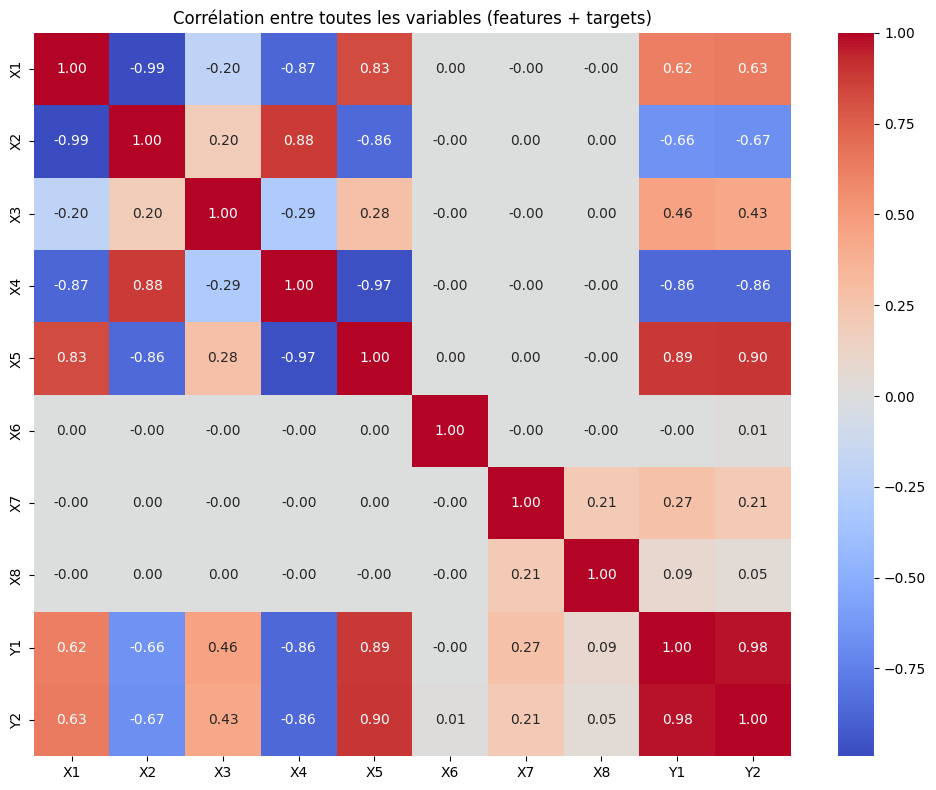

In [3]:
# Analyse préliminaire sur le dataset energy_efficiency

# Taille des figures plus petite pour une meilleure lisibilité
plt.rcParams["figure.figsize"] = (8, 4)

# 1. Statistiques descriptives
print("Statistiques descriptives des variables :")
display(X.describe())
display(y.describe())

# 2. Matrice de corrélation entre toutes les variables (features + targets)
print("Matrice de corrélation (features + targets) :")
all_data = pd.concat([X, y], axis=1) # concaténer les features et les targets pour l'analyse de corrélation
corr_matrix = all_data.corr() # calcul de la matrice de corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f") # affichage de la matrice de corrélation
plt.title("Corrélation entre toutes les variables (features + targets)")
plt.tight_layout()
plt.show()

In [4]:
# Dictionnaire des variables (features et targets)
feature_descriptions = {
    'X1': 'Relative Compactness',
    'X2': 'Surface Area',
    'X3': 'Wall Area',
    'X4': 'Roof Area',
    'X5': 'Overall Height',
    'X6': 'Orientation',
    'X7': 'Glazing Area',
    'X8': 'Glazing Area Distribution',
    'Y1': 'Heating Load',
    'Y2': 'Cooling Load'
}

print("Dictionnaire des variables :")
for key, desc in feature_descriptions.items(): # afficher chaque variable avec sa description
    print(f"{key}: {desc}") # syntaxe des dicos en Python

Dictionnaire des variables :
X1: Relative Compactness
X2: Surface Area
X3: Wall Area
X4: Roof Area
X5: Overall Height
X6: Orientation
X7: Glazing Area
X8: Glazing Area Distribution
Y1: Heating Load
Y2: Cooling Load


In [5]:
# Prétraitement

# Diviser les données en ensembles d'entraînement (60%), de validation (20%) et de test (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 20% pour le test
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42) # 25% de 80% = 20% pour la validation
# random_state fixé à 42 pour reproductibilité des résultts  à chaque itération

# Standardisation des features
scaler = StandardScaler() # créer un objet StandardScaler afin de standardiser les features
X_train_scaled = scaler.fit_transform(X_train) # ajuster le scaler sur les données d'entraînement et transformer ces données
X_val_scaled = scaler.transform(X_val) # transformer les données de validation avec le scaler ajusté
X_test_scaled = scaler.transform(X_test) # transformer les données de test avec le scaler ajusté

print("Shapes:")
print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_val:", y_val.shape, "y_test:", y_test.shape)

Shapes:
X_train: (460, 8) X_val: (154, 8) X_test: (154, 8)
y_train: (460, 2) y_val: (154, 2) y_test: (154, 2)


In [9]:
# Modélisation : comparaison de plusieurs modèles de régression

simple_models = {
    "Linear Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]), # pipeline avec standardisation + régression linéaire
    "Random Forest": RandomForestRegressor(random_state=42), # modèle de forêt aléatoire
    "Gradient Boosting": GradientBoostingRegressor(random_state=42), # modèle de gradient boosting
    "k Nearest Neighbours": KNeighborsRegressor(n_neighbors=4) # modèle des k plus proches voisins, pour K=4
}

model_scores = [] # intialisation : liste pour stocker les scores des modèles

for target in y.columns: # boucle sur chaque target (Y1 et Y2)
    print(f"\n=== Target: {target} ===")
    y_train_target = y_train[target] # extraction de la target d'entraînement
    y_val_target = y_val[target] # extraction de la target de validation
    for name, model in simple_models.items(): # boucle sur chaque modèle
        print(f"\n{name}")
        model.fit(X_train_scaled, y_train_target) # entraînement du modèle : fit sur les données d'entraînement
        y_pred = model.predict(X_val_scaled) # prédictions sur les données de validation
        # on compute les métriques d'évaluation classiques choisies.
        mse = mean_squared_error(y_val_target, y_pred)
        r2 = r2_score(y_val_target, y_pred)
        mae = mean_absolute_error(y_val_target, y_pred)
        rmse = np.sqrt(mse)
        model_scores.append({
            "Target": target,
            "Model": name,
            "MSE": mse,
            "R2": r2,
            "MAE": mae,
            "RMSE": rmse
        }) # on stocke les scores dans la liste
        print("MSE (val):", mse)
        print("R2 (val):", r2)
        print("MAE (val):", mae)
        print("RMSE (val):", rmse)

# Réseau de neurones
tuned_model = {
    "MLPRegressor": {
        "model": Pipeline([
            ('scaler', StandardScaler()),
            ('model', MLPRegressor(max_iter=300, random_state=42))
        ]),
        "params": {
            'model__hidden_layer_sizes': [(64,), (64, 32)],
            'model__alpha': [1e-4, 1e-3],
            'model__learning_rate_init': [0.001, 0.01]
        }
    }
} # dictionnaire pour stocker le modèle et les hyperparamètres à tuner

for target in y.columns:
    print(f"\n=== Target: {target} (réseau de neurones) ===")
    y_train_target = y_train[target] # extraction de la target d'entraînement
    y_val_target = y_val[target] # extraction de la target de validation
    for name, cfg in tuned_model.items(): # boucle sur chaque modèle à tuner
        print(f"\n{name} (GridSearchCV)")
        grid = GridSearchCV(cfg["model"], cfg["params"], cv=3, scoring='neg_mean_squared_error', verbose=0, n_jobs=-1) # GridSearchCV pour tuner les hyperparamètres, avec 3-fold CV : sélection des meilleurs hyperparamètres basés sur la MSE négative.
        grid.fit(X_train_scaled, y_train_target) # entraînement du GridSearchCV
        print("Best params:", grid.best_params_)
        best_model = grid.best_estimator_ # meilleur modèle avec les meilleurs hyperparamètres
        y_pred = best_model.predict(X_val_scaled) # prédictions sur les données de validation
        # on compute les métriques d'évaluation classiques choisies.
        mse = mean_squared_error(y_val_target, y_pred)
        r2 = r2_score(y_val_target, y_pred)
        mae = mean_absolute_error(y_val_target, y_pred)
        rmse = np.sqrt(mse)
        model_scores.append({
            "Target": target,
            "Model": name,
            "MSE": mse,
            "R2": r2,
            "MAE": mae,
            "RMSE": rmse
        }) # on stocke les scores dans la liste
        print("MSE (val):", mse)
        print("R2 (val):", r2)
        print("MAE (val):", mae)
        print("RMSE (val):", rmse)


=== Target: Y1 ===

Linear Regression
MSE (val): 9.040533060415328
R2 (val): 0.9175091489830902
MAE (val): 2.1291408861038983
RMSE (val): 3.0067479209962595

Random Forest
MSE (val): 0.3008736429870113
R2 (val): 0.9972546615677753
MAE (val): 0.3538454545454525
RMSE (val): 0.5485195010088623

Gradient Boosting
MSE (val): 0.2766203630815549
R2 (val): 0.9974759619807025
MAE (val): 0.3560725177018731
RMSE (val): 0.5259471105363684

k Nearest Neighbours
MSE (val): 6.280641030844157
R2 (val): 0.9426919386164765
MAE (val): 1.677613636363636
RMSE (val): 2.506120713541979

=== Target: Y2 ===

Linear Regression
MSE (val): 9.834998795891275
R2 (val): 0.894378022263448
MAE (val): 2.1979540938800226
RMSE (val): 3.136080164136637

Random Forest
MSE (val): 3.8035653940259735
R2 (val): 0.959151993029713
MAE (val): 1.1756129870129848
RMSE (val): 1.9502731588231361

Gradient Boosting
MSE (val): 2.5679905746473937
R2 (val): 0.9724213241981895
MAE (val): 1.1458717816815278
RMSE (val): 1.6024951090868869


C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Best params: {'model__alpha': 0.001, 'model__hidden_layer_sizes': (64, 32), 'model__learning_rate_init': 0.01}
MSE (val): 0.5360119080239655
R2 (val): 0.9951091292789251
MAE (val): 0.5246040357672095
RMSE (val): 0.7321283412243822

=== Target: Y2 (réseau de neurones) ===

MLPRegressor (GridSearchCV)
Best params: {'model__alpha': 0.001, 'model__hidden_layer_sizes': (64, 32), 'model__learning_rate_init': 0.01}
MSE (val): 2.0409263890550826
R2 (val): 0.9780816768664198
MAE (val): 0.989881914538036
RMSE (val): 1.4286099499356297


C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


C:\Users\matth\AppData\Local\Temp\ipykernel_4236\4204634926.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_eval[df_eval["Target"] == target], x="Model", y="MSE", palette="Blues_d")


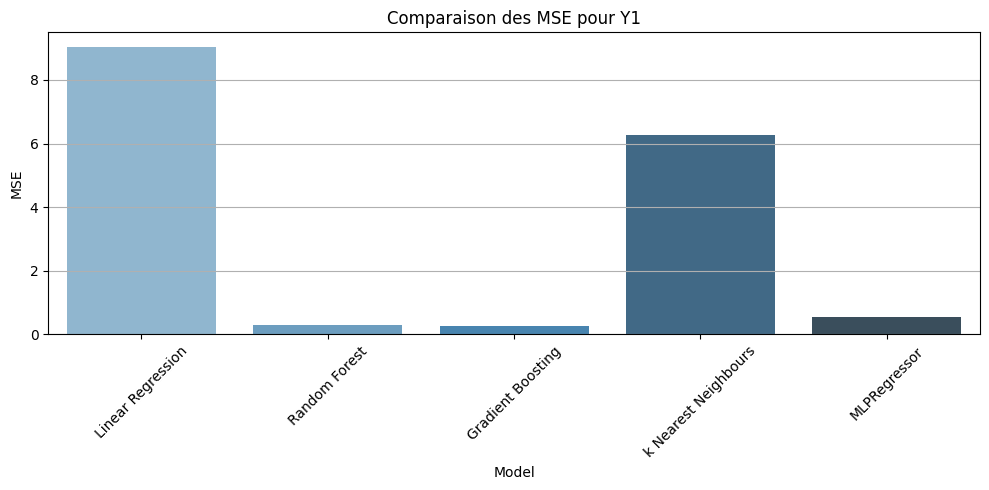

C:\Users\matth\AppData\Local\Temp\ipykernel_4236\4204634926.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_eval[df_eval["Target"] == target], x="Model", y="MSE", palette="Blues_d")


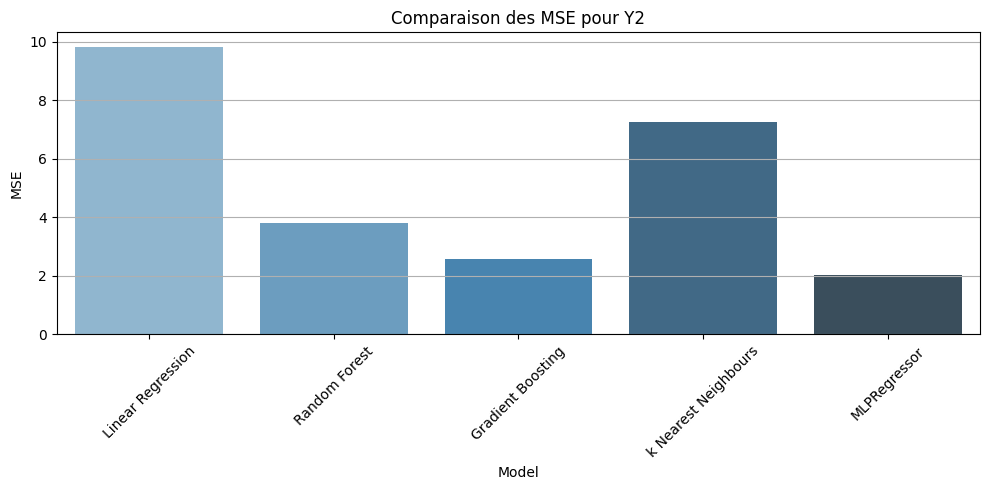

C:\Users\matth\AppData\Local\Temp\ipykernel_4236\4204634926.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_eval[df_eval["Target"] == target], x="Model", y="R2", palette="Greens_d")


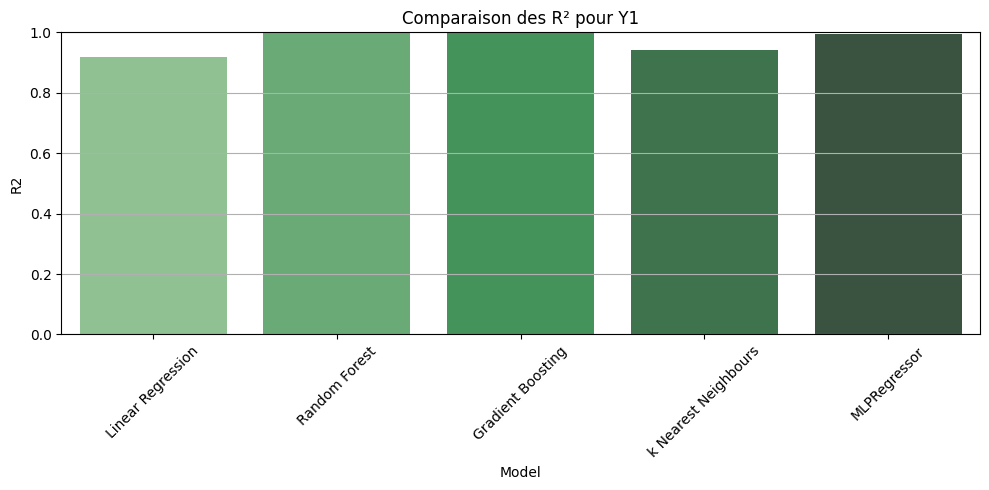

C:\Users\matth\AppData\Local\Temp\ipykernel_4236\4204634926.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_eval[df_eval["Target"] == target], x="Model", y="R2", palette="Greens_d")


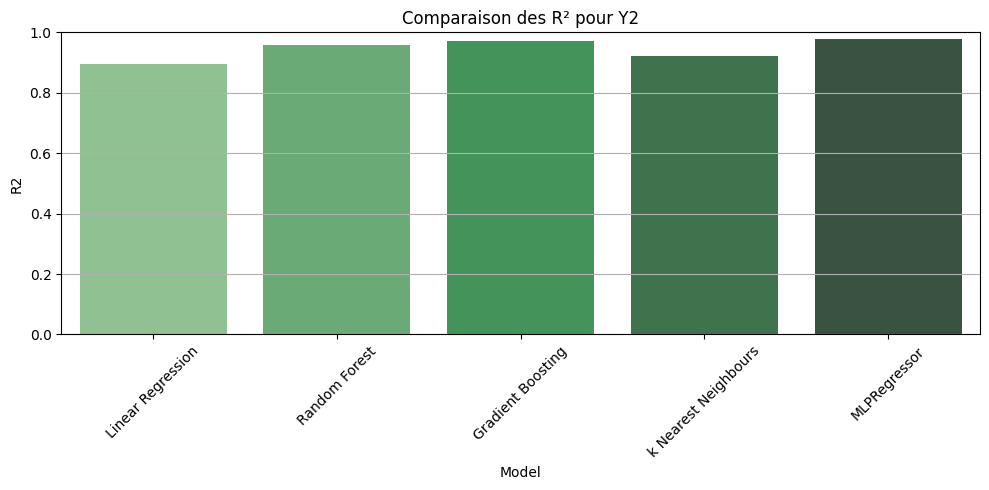

C:\Users\matth\AppData\Local\Temp\ipykernel_4236\4204634926.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_eval[df_eval["Target"] == target], x="Model", y="RMSE", palette="Reds_d")


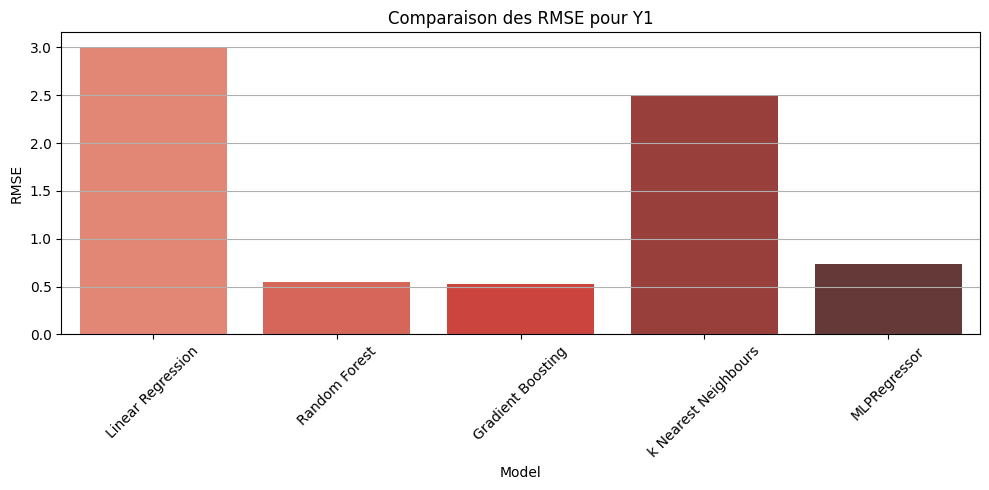

C:\Users\matth\AppData\Local\Temp\ipykernel_4236\4204634926.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_eval[df_eval["Target"] == target], x="Model", y="RMSE", palette="Reds_d")


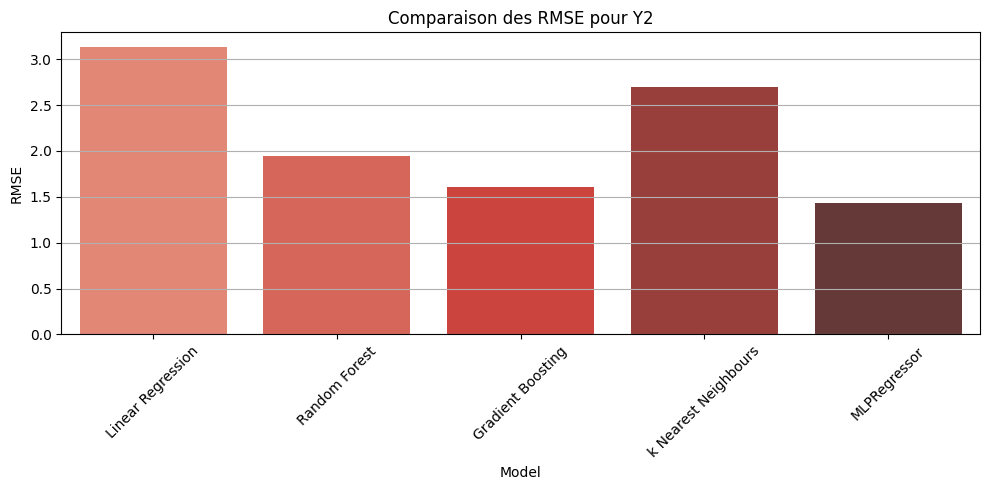

C:\Users\matth\AppData\Local\Temp\ipykernel_4236\4204634926.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_eval[df_eval["Target"] == target], x="Model", y="MAE", palette="Oranges_d")


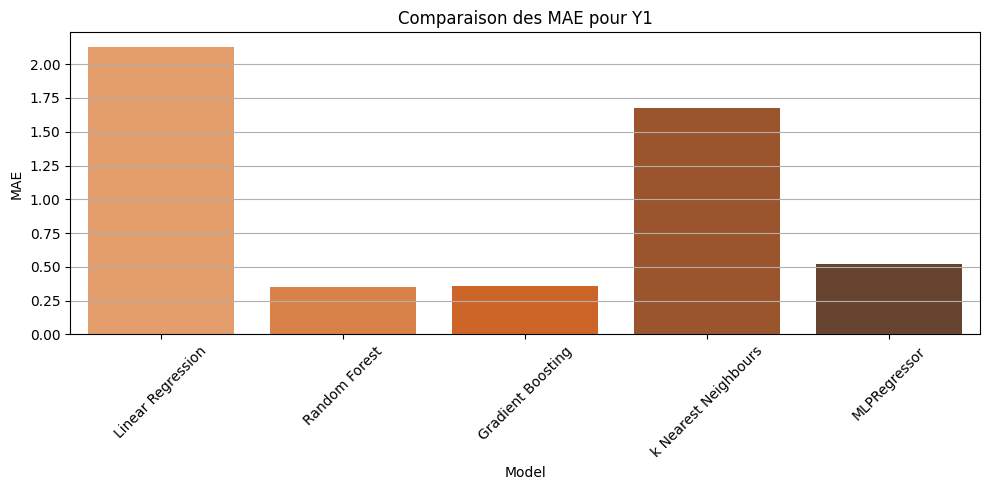

C:\Users\matth\AppData\Local\Temp\ipykernel_4236\4204634926.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_eval[df_eval["Target"] == target], x="Model", y="MAE", palette="Oranges_d")


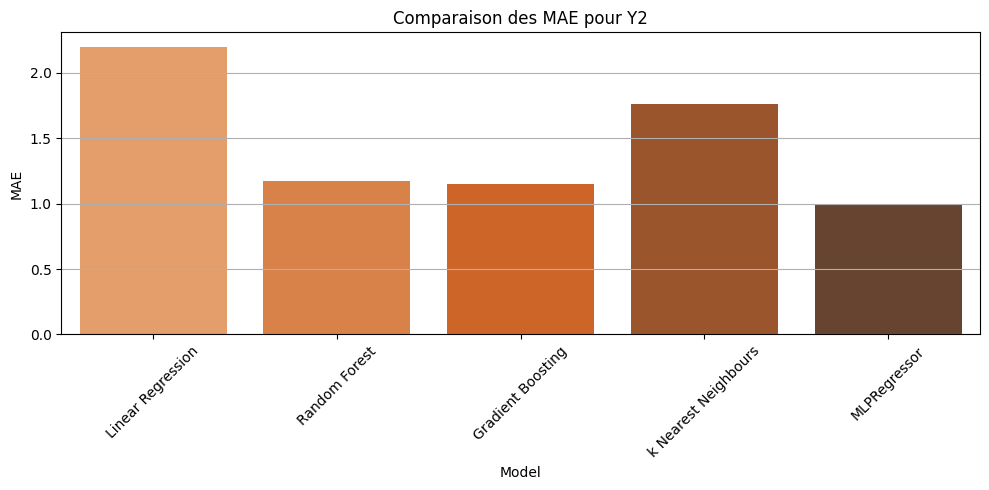


Meilleur modèle pour Y1 : Gradient Boosting
  - MSE : 0.2766
  - R²  : 0.9975
  - RMSE : 0.5259
  - MAE : 0.3561

Meilleur modèle pour Y2 : MLPRegressor
  - MSE : 2.0409
  - R²  : 0.9781
  - RMSE : 1.4286
  - MAE : 0.9899


In [11]:
# Visualisation des scores des modèles pour chaque cible
df_eval = pd.DataFrame(model_scores)

targets = df_eval["Target"].unique()

# 1. Barplot des MSE pour chaque cible
for target in targets:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_eval[df_eval["Target"] == target], x="Model", y="MSE", palette="Blues_d")
    plt.title(f"Comparaison des MSE pour {target}")
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

# 2. Barplot des R² pour chaque cible
for target in targets:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_eval[df_eval["Target"] == target], x="Model", y="R2", palette="Greens_d")
    plt.title(f"Comparaison des R² pour {target}")
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

# 3. Barplot des RMSE pour chaque cible
for target in targets:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_eval[df_eval["Target"] == target], x="Model", y="RMSE", palette="Reds_d")
    plt.title(f"Comparaison des RMSE pour {target}")
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

# 4. Barplot des MAE pour chaque cible
for target in targets:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_eval[df_eval["Target"] == target], x="Model", y="MAE", palette="Oranges_d")
    plt.title(f"Comparaison des MAE pour {target}")
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

# 5. Affichage du meilleur modèle pour chaque cible
for target in targets:
    best_row = df_eval[df_eval["Target"] == target].sort_values("MSE").iloc[0]
    print(f"\nMeilleur modèle pour {target} : {best_row['Model']}")
    print(f"  - MSE : {best_row['MSE']:.4f}")
    print(f"  - R²  : {best_row['R2']:.4f}")
    print(f"  - RMSE : {best_row['RMSE']:.4f}")
    print(f"  - MAE : {best_row['MAE']:.4f}")

### Amélio : prédire $Y_2$ à partir de $Y_1$

In [ ]:
(n,p) = X.shape
# Create and fit the model
y1, y2 = y.iloc[:,0], y.iloc[:,1]

linear_model = LinearRegression()
kf = KFold(n_splits=int(np.sqrt(n)), shuffle=True, random_state=42) #n_splits optimal = 540

# oninitialise les listes pour stocker les scores
mse_scores = []
rmse_scores = []
mae_scores = []


## _________________

#Prédiction y2 à partir de Y1
print("Prédiction y2 à partir de Y1")
for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    y1_train, y1_test = y1.values[train_idx], y1.values[test_idx]
    y2_train, y2_test = y2.values[train_idx], y2.values[test_idx]

    linear_model.fit(y1_train.reshape(-1,1), y2_train)
    y2_pred = linear_model.predict(y1_test.reshape(-1,1))

    mse = mean_squared_error(y2_test, y2_pred)
    mse_scores.append(mse)

    rmse = np.sqrt(mse)
    rmse_scores.append(rmse)

    mae = mean_absolute_error(y2_test, y2_pred)
    mae_scores.append(mae)


theta1 = linear_model.coef_
intercept1 = linear_model.intercept_
print("Coefficients:", theta1)
print("Intercept:", intercept1)
print("\nMSE moyen :", np.mean(mse_scores))
print("RMSE moyen :", np.mean(rmse_scores))
print("MAE moyen :", np.mean(mae_scores))

def R2(theta, intercept):
    R = 1 - (np.linalg.norm(y2- y1.values.reshape(-1,1)@ theta-intercept)**2/np.linalg.norm(y2-np.mean(y2))**2)
    return R
    
R = R2(theta1, intercept1)
print("Coefficient de corrélation :", R)

Prédiction y2 à partir de Y1
Coefficients: [0.91806116]
Intercept: 4.099810795575987

MSE moyen : 4.334727787249087
RMSE moyen : 2.063374297386672
MAE moyen : 1.4762716384101864
Coefficient de corrélation : 0.9523009322920348


In [ ]:
#Prédiction Y2 à partir de X : même process de calcul que précédemment.
print("Prédiction y2 à partir de X")
linear_model_x = LinearRegression()
kf = KFold(n_splits=int(np.sqrt(n)), shuffle=True, random_state=42) #n_splits optimal = 540

mse_scores_x = []
rmse_scores_x = []
mae_scores_x = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    X_train, X_test = X.values[train_idx], X.values[test_idx]
    y2_train_x, y2_test_x = y2.values[train_idx], y2.values[test_idx]

    linear_model_x.fit(X_train, y2_train_x)
    y2_pred_x = linear_model_x.predict(X_test)

    mse_x = mean_squared_error(y2_test_x, y2_pred_x)
    mse_scores_x.append(mse_x)
    rmse_x = np.sqrt(mse_x)
    rmse_scores_x.append(rmse_x)
    mae_x = mean_absolute_error(y2_test_x, y2_pred_x)
    mae_scores_x.append(mae_x)

theta2 = linear_model_x.coef_
intercept2 = linear_model_x.intercept_

print("Coefficients:", theta2)
print("Intercept:", intercept2)
print("\nMSE moyen :", np.mean(mse_scores_x))
print("RMSE moyen :", np.mean(rmse_scores_x))
print("MAE moyen :", np.mean(mae_scores_x))

def R2(theta, intercept):
    R = 1 - (np.linalg.norm(y2- X @ theta-intercept)**2/np.linalg.norm(y2-np.mean(y2))**2)
    return R

R_x = R2(theta2, intercept2)
print("Coefficient de corrélation :", R_x)

Prédiction y2 à partir de X
Coefficients: [-7.24171192e+01 -6.89148680e-02  2.39063241e-02 -4.64105960e-02
  4.17666332e+00  1.29558134e-01  1.47143121e+01  3.16389992e-02]
Intercept: 100.87910957501406

MSE moyen : 10.360880479772577
RMSE moyen : 3.1585702609322133
MAE moyen : 2.2677910083629516
Coefficient de corrélation : 0.8877817666138245


##### Critique :
On se rend compte qu'en appliquant la même méthode d'apprentissage (la régression linéaire) pour prédire Y2, le MSE et le coefficient de régression sont plus satisfaisants en utilisant Y1 qu'en utlisant la matrice X.

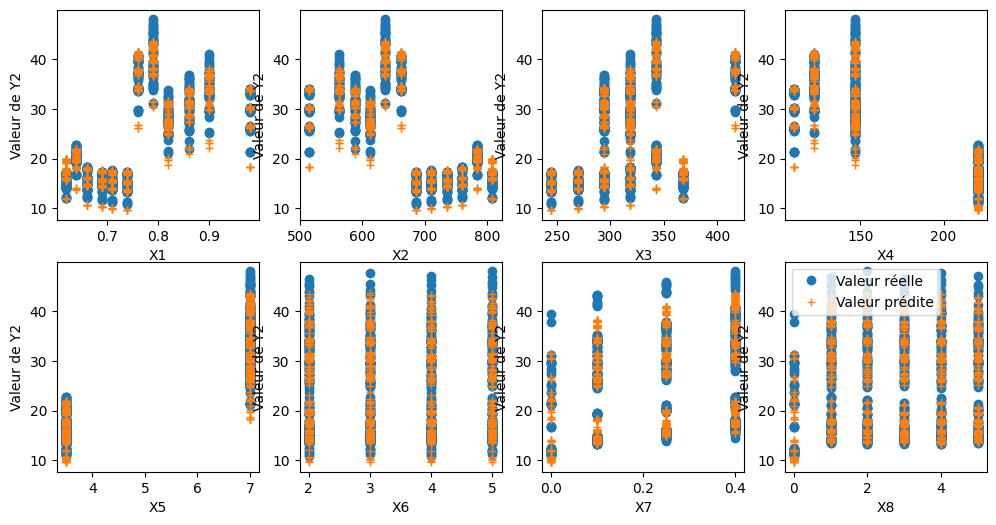

In [15]:
# affichage visuel de prédiction Y2 à partir de Y1.

y2_pred = linear_model.predict(y1.values.reshape(-1,1))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(0,int(p/2)):
    axes[0,i].plot(X.iloc[:,i],y2, 'o', label="Valeur réelle")
    axes[0,i].plot(X.iloc[:,i],y2_pred, '+', label="Valeur prédite")
    axes[0,i].set_xlabel(f"X{i+1}")
    axes[0,i].set_ylabel("Valeur de Y2")
for i in range(int(p/2),p):
    axes[1,i-int(p/2)].plot(X.iloc[:,i],y2, 'o', label="Valeur réelle")
    axes[1,i-int(p/2)].plot(X.iloc[:,i],y2_pred, '+', label="Valeur prédite")
    axes[1,i-int(p/2)].set_xlabel(f"X{i+1}")
    axes[1,i-int(p/2)].set_ylabel("Valeur de Y2")
plt.legend()
plt.show()

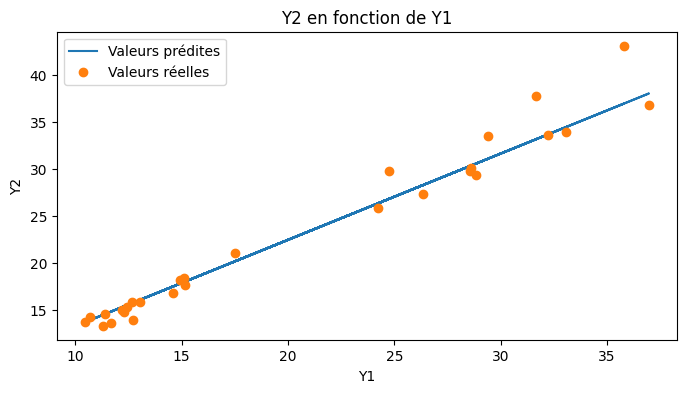

In [16]:
# affichage visuel de prédiction Y2 à partir de Y1.

y2_test_pred = linear_model.predict(y1_test.reshape(-1,1))
plt.plot(y1_test, y2_test_pred, label='Valeurs prédites')
plt.plot(y1_test, y2_test, 'o', label='Valeurs réelles')
plt.title('Y2 en fonction de Y1')
plt.xlabel('Y1')
plt.ylabel('Y2')
plt.legend()
plt.show()

Merci de votre attention, c'est la fin de notre Jupyter Notebook de DAML !!!